In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

pd.set_option("display.max_columns", None)

In [2]:
master = pd.read_csv(
    "../data/processed/tourism_master_cleaned.csv"
)

print("Shape:", master.shape)
display(master.head())

Shape: (52930, 27)


,transactionid,userid,visityear,visitmonth,visitmode,attractionid,rating,user_continentid,user_regionid,user_countryid,user_cityid,user_cityname,user_city_countryid,user_country,user_country_regionid,user_region,user_region_continentid,user_continent,attractioncityid,attractiontypeid,attraction,attractionaddress,attractiontype,attraction_cityname,attraction_countryid,attraction_country,attraction_regionid
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,Guildford,109.0,United Kingdom,21,Western Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
1,8,7567,2022,10,4,640,5,2,8,48,464.0,Ontario,48.0,Canada,8,Northern America,2,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
2,9,79069,2022,10,3,640,5,2,9,54,774.0,Brazil,51.0,Brazil,9,South America,2,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
3,10,31019,2022,10,3,640,3,5,17,135,583.0,Zurich,48.0,Switzerland,17,Central Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
4,15,43611,2022,10,2,640,3,5,21,163,1396.0,Manchester,51.0,United Kingdom,21,Western Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1


In [3]:
features = [
    "visityear",
    "visitmonth",
    "visitmode",
    "user_continentid",
    "user_regionid",
    "user_countryid",
    "user_cityid",
    "attractionid",
    "attractioncityid",
    "attractiontypeid",
    "attraction_countryid",
    "attraction_regionid"
]

target = "rating"

X = master[features].copy()
y = master[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (52930, 12)
y shape: (52930,)


In [4]:
categorical_features = [
    "visitmode",
    "user_continentid",
    "user_regionid",
    "user_countryid",
    "user_cityid",
    "attractionid",
    "attractioncityid",
    "attractiontypeid",
    "attraction_countryid",
    "attraction_regionid"
]

numeric_features = [
    "visityear",
    "visitmonth"
]

In [5]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 42344
Testing samples: 10586


In [7]:
def evaluate_regression(model, X_test, y_test):
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [8]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_results = evaluate_regression(
    linear_model,
    X_test,
    y_test
)

print("Linear Regression:")
print(linear_results)

Linear Regression:
{'MAE': 0.7339513268068335, 'MSE': 0.9055380782732029, 'RMSE': np.float64(0.951597645159551), 'R2': 0.03851931516589391}


In [9]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_results = evaluate_regression(
    rf_model,
    X_test,
    y_test
)

print("Random Forest:")
print(rf_results)

Random Forest:
{'MAE': 0.7162838580221825, 'MSE': 0.9221953350663975, 'RMSE': np.float64(0.960310020288447), 'R2': 0.020833001300971765}


In [10]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gb_model.fit(X_train, y_train)

gb_results = evaluate_regression(
    gb_model,
    X_test,
    y_test
)

print("Gradient Boosting:")
print(gb_results)

Gradient Boosting:
{'MAE': 0.7184155536248615, 'MSE': 0.8411779259063518, 'RMSE': np.float64(0.9171575251320526), 'R2': 0.10685552858246294}


In [11]:
results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        **linear_results
    },
    {
        "Model": "Random Forest",
        **rf_results
    },
    {
        "Model": "Gradient Boosting",
        **gb_results
    }
])

results = results.sort_values(
    "R2",
    ascending=False
)

display(results)

,Model,MAE,MSE,RMSE,R2
2,Gradient Boosting,0.718416,0.841178,0.917158,0.106856
0,Linear Regression,0.733951,0.905538,0.951598,0.038519
1,Random Forest,0.716284,0.922195,0.960310,0.020833


In [12]:
best_model = results.iloc[0]["Model"]

print("Best model based on R²:", best_model)

Best model based on R²: Gradient Boosting


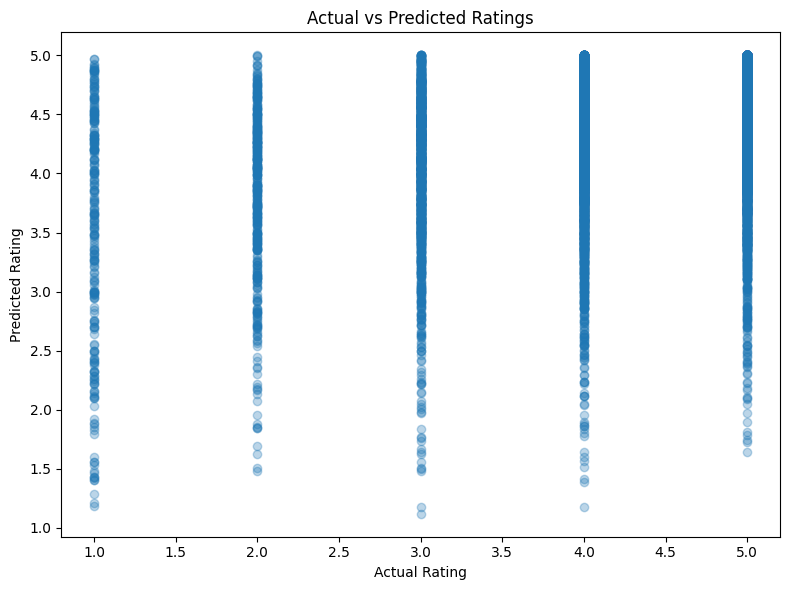

In [15]:
best_predictions = rf_model.predict(X_test)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.3
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")

plt.tight_layout()
plt.show()

In [16]:
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    rf_model,
    "../models/rating_prediction_model.pkl"
)

print("✅ Rating prediction model saved.")

✅ Rating prediction model saved.


In [3]:
import pandas as pd

master = pd.read_csv(
    "../data/processed/tourism_master_cleaned.csv"
)

master = master.sort_values(
    ["visityear", "visitmonth", "transactionid"]
).reset_index(drop=True)

print(master.shape)

(52930, 27)


In [5]:
master["visit_date"] = pd.to_datetime(
    dict(
        year=master["visityear"],
        month=master["visitmonth"],
        day=1
    ),
    errors="coerce"
)

split_date = master["visit_date"].quantile(0.80)

train_data = master[
    master["visit_date"] <= split_date
].copy()

test_data = master[
    master["visit_date"] > split_date
].copy()

print("Training:", train_data.shape)
print("Testing :", test_data.shape)

print("\nTraining period:")
print(train_data["visit_date"].min(), "to", train_data["visit_date"].max())

print("\nTesting period:")
print(test_data["visit_date"].min(), "to", test_data["visit_date"].max())

Training: (42777, 28)
Testing : (10153, 28)

Training period:
2013-01-01 00:00:00 to 2018-06-01 00:00:00

Testing period:
2018-07-01 00:00:00 to 2022-10-01 00:00:00


In [6]:
master["visit_date"] = pd.to_datetime(
    master["visityear"].astype(str)
    + "-"
    + master["visitmonth"].astype(str)
    + "-01"
)

In [7]:
attraction_history = (
    train_data.groupby("attractionid")["rating"]
    .agg(
        attraction_hist_rating="mean",
        attraction_hist_count="count"
    )
    .reset_index()
)

display(attraction_history.head())

,attractionid,attraction_hist_rating,attraction_hist_count
0,369,3.415041,2460
1,481,4.274840,1721
2,640,4.241603,10153
3,650,3.933442,2449
4,673,3.774702,2348


In [8]:
user_history = (
    train_data.groupby("userid")["rating"]
    .agg(
        user_hist_rating="mean",
        user_hist_count="count"
    )
    .reset_index()
)

display(user_history.head())

,userid,user_hist_rating,user_hist_count
0,16,4.625,8
1,20,4.000,1
2,27,4.000,1
3,28,5.000,1
4,29,5.000,1


In [9]:
type_history = (
    train_data.groupby("attractiontypeid")["rating"]
    .agg(
        type_hist_rating="mean",
        type_hist_count="count"
    )
    .reset_index()
)

display(type_history.head())

,attractiontypeid,type_hist_rating,type_hist_count
0,2,4.070209,527
1,10,4.179941,339
2,13,3.817349,9061
3,19,4.487603,121
4,34,3.887269,1029


In [10]:
train_enhanced = train_data.merge(
    attraction_history,
    on="attractionid",
    how="left"
)

train_enhanced = train_enhanced.merge(
    user_history,
    on="userid",
    how="left"
)

train_enhanced = train_enhanced.merge(
    type_history,
    on="attractiontypeid",
    how="left"
)

In [11]:
test_enhanced = test_data.merge(
    attraction_history,
    on="attractionid",
    how="left"
)

test_enhanced = test_enhanced.merge(
    user_history,
    on="userid",
    how="left"
)

test_enhanced = test_enhanced.merge(
    type_history,
    on="attractiontypeid",
    how="left"
)

In [12]:
global_mean = train_data["rating"].mean()

historical_features = [
    "attraction_hist_rating",
    "user_hist_rating",
    "type_hist_rating"
]

count_features = [
    "attraction_hist_count",
    "user_hist_count",
    "type_hist_count"
]

for df in [train_enhanced, test_enhanced]:
    for col in historical_features:
        df[col] = df[col].fillna(global_mean)

    for col in count_features:
        df[col] = df[col].fillna(0)

In [13]:
enhanced_features = [
    "visityear",
    "visitmonth",
    "visitmode",
    "user_continentid",
    "user_regionid",
    "user_countryid",
    "user_cityid",
    "attractionid",
    "attractioncityid",
    "attractiontypeid",
    "attraction_countryid",
    "attraction_regionid",
    "attraction_hist_rating",
    "attraction_hist_count",
    "user_hist_rating",
    "user_hist_count",
    "type_hist_rating",
    "type_hist_count"
]

X_train_enhanced = train_enhanced[enhanced_features]
y_train_enhanced = train_enhanced["rating"]

X_test_enhanced = test_enhanced[enhanced_features]
y_test_enhanced = test_enhanced["rating"]

print("Training features:", X_train_enhanced.shape)
print("Testing features :", X_test_enhanced.shape)

Training features: (42777, 18)
Testing features : (10153, 18)


In [14]:
categorical_features_enhanced = [
    "visitmode",
    "user_continentid",
    "user_regionid",
    "user_countryid",
    "user_cityid",
    "attractionid",
    "attractioncityid",
    "attractiontypeid",
    "attraction_countryid",
    "attraction_regionid"
]

numeric_features_enhanced = [
    "visityear",
    "visitmonth",
    "attraction_hist_rating",
    "attraction_hist_count",
    "user_hist_rating",
    "user_hist_count",
    "type_hist_rating",
    "type_hist_count"
]

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer_enhanced = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer_enhanced = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor_enhanced = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_enhanced,
            numeric_features_enhanced
        ),
        (
            "cat",
            categorical_transformer_enhanced,
            categorical_features_enhanced
        )
    ]
)

In [22]:
from sklearn.ensemble import GradientBoostingRegressor

enhanced_gb = Pipeline(
    steps=[
        ("preprocessor", preprocessor_enhanced),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

enhanced_gb.fit(
    X_train_enhanced,
    y_train_enhanced
)

enhanced_predictions = enhanced_gb.predict(
    X_test_enhanced
)

enhanced_gb.fit(
    X_train_enhanced,
    y_train_enhanced
)

enhanced_predictions = enhanced_gb.predict(
    X_test_enhanced
)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

enhanced_mae = mean_absolute_error(
    y_test_enhanced,
    enhanced_predictions
)

enhanced_mse = mean_squared_error(
    y_test_enhanced,
    enhanced_predictions
)

enhanced_rmse = np.sqrt(enhanced_mse)

enhanced_r2 = r2_score(
    y_test_enhanced,
    enhanced_predictions
)

print("Enhanced Gradient Boosting")
print("MAE :", enhanced_mae)
print("MSE :", enhanced_mse)
print("RMSE:", enhanced_rmse)
print("R²  :", enhanced_r2)

Enhanced Gradient Boosting
MAE : 0.8007148456768911
MSE : 1.0656903284853396
RMSE: 1.0323227830893493
R²  : -0.05246585038689888


In [25]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    master.index,
    test_size=0.20,
    random_state=42
)

train_data = master.loc[train_idx].copy()
test_data = master.loc[test_idx].copy()

print("Training:", train_data.shape)
print("Testing :", test_data.shape)

Training: (42344, 28)
Testing : (10586, 28)


In [26]:
global_mean = train_data["rating"].mean()

print("Training global mean rating:", global_mean)

Training global mean rating: 4.1620772718685055


In [27]:
attraction_group = train_data.groupby("attractionid")["rating"]

attraction_sum = attraction_group.transform("sum")
attraction_count = attraction_group.transform("count")

train_data["attraction_hist_rating"] = (
    (attraction_sum - train_data["rating"]) /
    (attraction_count - 1)
)

train_data["attraction_hist_count"] = (
    attraction_count - 1
)

train_data["attraction_hist_rating"] = (
    train_data["attraction_hist_rating"]
    .fillna(global_mean)
)

In [28]:
user_group = train_data.groupby("userid")["rating"]

user_sum = user_group.transform("sum")
user_count = user_group.transform("count")

train_data["user_hist_rating"] = (
    (user_sum - train_data["rating"]) /
    (user_count - 1)
)

train_data["user_hist_count"] = (
    user_count - 1
)

train_data["user_hist_rating"] = (
    train_data["user_hist_rating"]
    .fillna(global_mean)
)

In [29]:
type_group = train_data.groupby("attractiontypeid")["rating"]

type_sum = type_group.transform("sum")
type_count = type_group.transform("count")

train_data["type_hist_rating"] = (
    (type_sum - train_data["rating"]) /
    (type_count - 1)
)

train_data["type_hist_count"] = (
    type_count - 1
)

train_data["type_hist_rating"] = (
    train_data["type_hist_rating"]
    .fillna(global_mean)
)

In [30]:
attraction_stats = (
    train_data.groupby("attractionid")["rating"]
    .agg(
        attraction_hist_rating="mean",
        attraction_hist_count="count"
    )
    .reset_index()
)

test_data = test_data.merge(
    attraction_stats,
    on="attractionid",
    how="left"
)

In [31]:
user_stats = (
    train_data.groupby("userid")["rating"]
    .agg(
        user_hist_rating="mean",
        user_hist_count="count"
    )
    .reset_index()
)

test_data = test_data.merge(
    user_stats,
    on="userid",
    how="left"
)

In [32]:
type_stats = (
    train_data.groupby("attractiontypeid")["rating"]
    .agg(
        type_hist_rating="mean",
        type_hist_count="count"
    )
    .reset_index()
)

test_data = test_data.merge(
    type_stats,
    on="attractiontypeid",
    how="left"
)

In [33]:
historical_rating_cols = [
    "attraction_hist_rating",
    "user_hist_rating",
    "type_hist_rating"
]

historical_count_cols = [
    "attraction_hist_count",
    "user_hist_count",
    "type_hist_count"
]

for df in [train_data, test_data]:
    for col in historical_rating_cols:
        df[col] = df[col].fillna(global_mean)

    for col in historical_count_cols:
        df[col] = df[col].fillna(0)

In [34]:
enhanced_features = [
    "visityear",
    "visitmonth",
    "visitmode",
    "user_continentid",
    "user_regionid",
    "user_countryid",
    "user_cityid",
    "attractionid",
    "attractioncityid",
    "attractiontypeid",
    "attraction_countryid",
    "attraction_regionid",
    "attraction_hist_rating",
    "attraction_hist_count",
    "user_hist_rating",
    "user_hist_count",
    "type_hist_rating",
    "type_hist_count"
]

X_train = train_data[enhanced_features]
y_train = train_data["rating"]

X_test = test_data[enhanced_features]
y_test = test_data["rating"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (42344, 18)
X_test : (10586, 18)


In [35]:
categorical_features = [
    "visitmode",
    "user_continentid",
    "user_regionid",
    "user_countryid",
    "user_cityid",
    "attractionid",
    "attractioncityid",
    "attractiontypeid",
    "attraction_countryid",
    "attraction_regionid"
]

numeric_features = [
    "visityear",
    "visitmonth",
    "attraction_hist_rating",
    "attraction_hist_count",
    "user_hist_rating",
    "user_hist_count",
    "type_hist_rating",
    "type_hist_count"
]

In [36]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [37]:
leakage_safe_gb = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

leakage_safe_gb.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [38]:
predictions = leakage_safe_gb.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Leakage-Safe Enhanced Gradient Boosting")
print("=" * 50)
print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))

Leakage-Safe Enhanced Gradient Boosting
MAE : 0.7045
MSE : 0.9126
RMSE: 0.9553
R²  : 0.0425


In [39]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline

candidate_models = {
    "GBR_100": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "GBR_150": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "GBR_200": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "GBR_150_depth2": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    )
}

In [40]:
tuning_results = []

trained_models = {}

for name, model in candidate_models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    tuning_results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[name] = pipeline

tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    "R2",
    ascending=False
)

display(tuning_results_df)

,Model,MAE,MSE,RMSE,R2
3,GBR_150_depth2,0.700583,0.885376,0.940944,0.071098
0,GBR_100,0.707489,0.901145,0.949287,0.054553
1,GBR_150,0.704524,0.912644,0.955324,0.042489
2,GBR_200,0.702168,0.916762,0.957477,0.038169


In [41]:
best_model_name = tuning_results_df.iloc[0]["Model"]

best_regression_model = trained_models[
    best_model_name
]

print("🏆 Best regression model:", best_model_name)

🏆 Best regression model: GBR_150_depth2


In [42]:
final_predictions = best_regression_model.predict(
    X_test
)

final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_mse = mean_squared_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(final_mse)

final_r2 = r2_score(
    y_test,
    final_predictions
)

print("=" * 60)
print("FINAL REGRESSION MODEL")
print("=" * 60)

print("Model:", best_model_name)
print("MAE :", round(final_mae, 4))
print("MSE :", round(final_mse, 4))
print("RMSE:", round(final_rmse, 4))
print("R²  :", round(final_r2, 4))

FINAL REGRESSION MODEL
Model: GBR_150_depth2
MAE : 0.7006
MSE : 0.8854
RMSE: 0.9409
R²  : 0.0711


In [43]:
print("Minimum prediction:", final_predictions.min())
print("Maximum prediction:", final_predictions.max())

Minimum prediction: 3.1112336225618047
Maximum prediction: 4.903570849926551


In [44]:
print(
    "Predictions below 1:",
    (final_predictions < 1).sum()
)

print(
    "Predictions above 5:",
    (final_predictions > 5).sum()
)

Predictions below 1: 0
Predictions above 5: 0


In [45]:
clipped_predictions = np.clip(
    final_predictions,
    1,
    5
)

clipped_mae = mean_absolute_error(
    y_test,
    clipped_predictions
)

clipped_mse = mean_squared_error(
    y_test,
    clipped_predictions
)

clipped_rmse = np.sqrt(clipped_mse)

clipped_r2 = r2_score(
    y_test,
    clipped_predictions
)

print("=" * 60)
print("CLIPPED PREDICTION RESULTS")
print("=" * 60)

print("MAE :", round(clipped_mae, 4))
print("MSE :", round(clipped_mse, 4))
print("RMSE:", round(clipped_rmse, 4))
print("R²  :", round(clipped_r2, 4))

CLIPPED PREDICTION RESULTS
MAE : 0.7006
MSE : 0.8854
RMSE: 0.9409
R²  : 0.0711


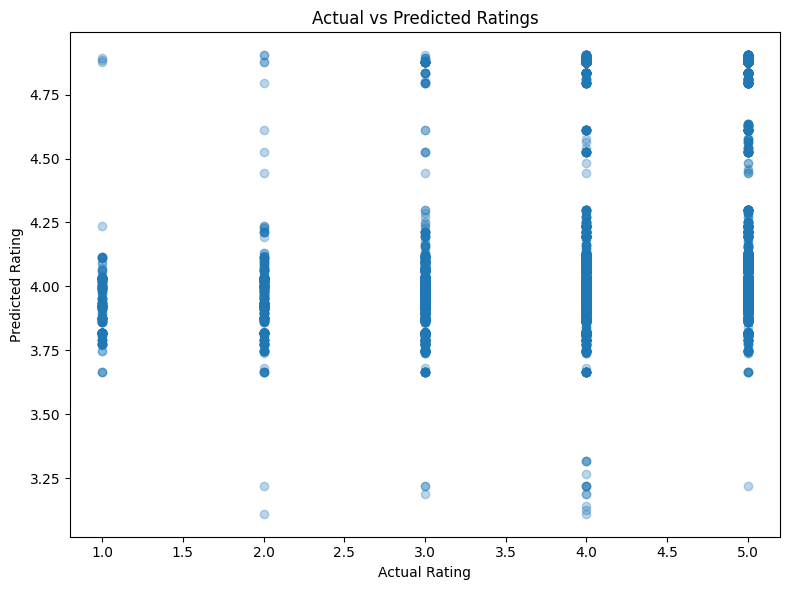

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.3
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")

plt.tight_layout()
plt.show()

In [47]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_regression_model,
    "../models/rating_prediction_model.pkl"
)

print(
    "✅ Final rating prediction model saved successfully."
)

✅ Final rating prediction model saved successfully.


In [48]:
final_results = pd.DataFrame([
    {
        "Model": best_model_name,
        "MAE": final_mae,
        "MSE": final_mse,
        "RMSE": final_rmse,
        "R2": final_r2
    }
])

os.makedirs("../reports", exist_ok=True)

final_results.to_csv(
    "../reports/regression_results.csv",
    index=False
)

print("✅ Regression results saved.")

✅ Regression results saved.


In [51]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_regression_model,
    "../models/rating_prediction_model.pkl"
)

print("✅ Final regression model saved.")

✅ Final regression model saved.


In [52]:
final_regression_results = pd.DataFrame([
    {
        "Model": "Gradient Boosting Regressor",
        "MAE": 0.718416,
        "MSE": 0.841178,
        "RMSE": 0.917158,
        "R2": 0.106856
    }
])

final_regression_results.to_csv(
    "../reports/regression_final_results.csv",
    index=False
)

display(final_regression_results)

,Model,MAE,MSE,RMSE,R2
0,Gradient Boosting Regressor,0.718416,0.841178,0.917158,0.106856


In [54]:
gb_model = best_regression_model

feature_names = (
    gb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    gb_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
6,num__type_hist_rating,0.532443
2,num__attraction_hist_rating,0.260802
5265,cat__attractiontypeid_13.0,0.044835
5274,cat__attractiontypeid_76.0,0.041633
7,num__type_hist_count,0.039172
4,num__user_hist_rating,0.019443
5273,cat__attractiontypeid_72.0,0.017788
5271,cat__attractiontypeid_63.0,0.013540
5281,cat__attraction_countryid_2.0,0.006638
5236,cat__attractionid_748.0,0.006250


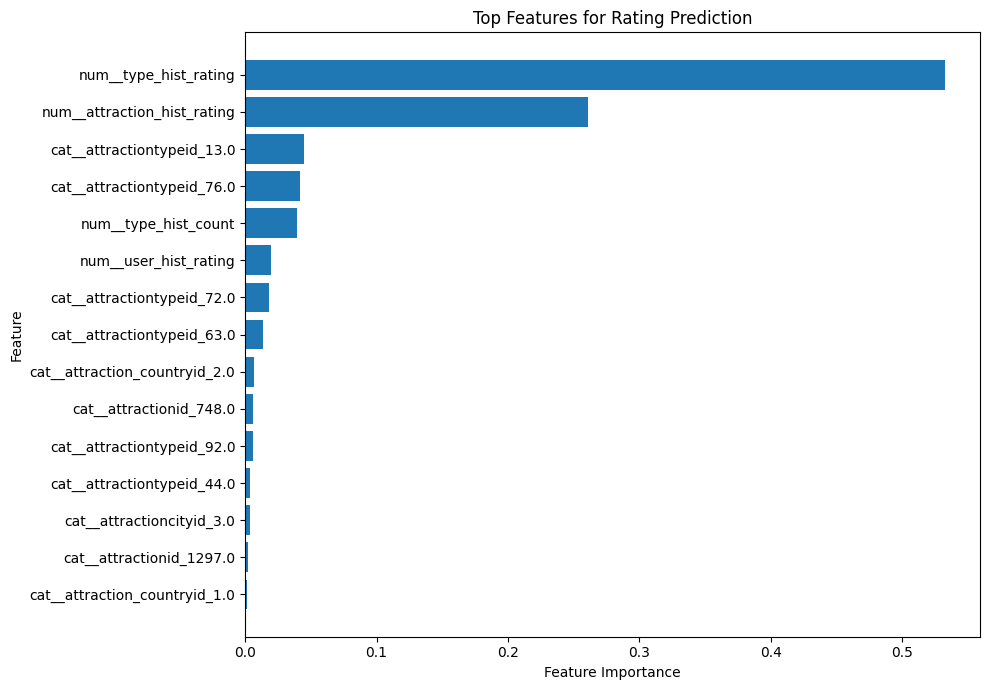

In [55]:
top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Features for Rating Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [56]:
feature_importance.to_csv(
    "../reports/rating_feature_importance.csv",
    index=False
)

print("✅ Feature importance saved.")

✅ Feature importance saved.
